In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

dates = pd.to_datetime([
    '2002-09-30', '2003-03-31', '2003-09-30', '2004-03-31', '2004-09-30', '2005-03-31',
    '2005-09-30', '2006-03-31', '2006-09-30', '2007-03-31', '2007-09-30', '2008-03-31',
    '2008-09-30', '2009-03-31', '2009-09-30', '2010-03-31', '2010-09-30', '2011-03-31',
    '2011-09-30', '2012-03-31', '2012-09-30', '2013-03-31', '2013-09-30', '2014-03-31',
    '2014-09-30', '2015-03-31', '2015-09-30', '2016-03-31', '2016-09-30', '2017-03-31',
    '2017-09-30', '2018-03-31', '2018-09-30', '2019-03-31', '2019-09-30', '2020-03-31',
    '2020-09-30', '2021-03-31', '2021-09-30', '2022-03-31', '2022-09-30', '2023-03-31',
    '2023-09-30', '2024-03-31', '2024-09-30', '2025-03-31'
])
seasons = ['Yala', 'Maha'] * 23
production = [22092.00, 19146.00, 21756.00, 23219.00, 24395.00, 29373.00, 26477.00, 30417.00, 27443.00, 33600.00, 27364.00, 37793.00, 36202.00, 
              48496.00, 33873.00, 41930.00, 31544.00, 43791.00, 36364.00, 39749.00, 34911.00, 47339.00, 36365.00, 49861.00, 32464.00, 53708.00, 
              30228.00, 49325.00, 32286.00, 60462.00, 43159.00, 37680.00, 49797.00, 51607.00, 39145.00, 38771.00, 48284.10, 42223.00, 52365.80, 
              37302.90, 47424.90, 40656.10, 34169.30, 46244.20, 34945.00, 39292.90]
excess = [2209.2, 1914.6, 2175.6, 2321.9, 2439.5, 3671.6, 3309.6, 3802.1, 3430.3, 5040, 3420.5, 5669, 5430.3, 7274.4, 3387.3, 6289.5, 3154.4, 
          6568.7, 4545.5, 4968.6, 3491.1, 7100.9, 4545.6, 7479.1, 3246.4, 8056.2, 3022.8, 7398.8, 3228.6, 9069.3, 5394.9, 5652, 6224.6, 6450.90, 
          5871.80, 3877.1, 7242.6, 5278, 6545.70, 5595.40, 5928.1, 6098, 5125, 5780.50, 4368.1, 4911.6]
df = pd.DataFrame({
    'ds': dates,
    'production': production,
    'y': excess,
    'season': seasons,
    'period': ['Pre-Crisis'] * 38 + ['Post-Crisis'] * 8
})
print(df.head())

          ds  production       y season      period
0 2002-09-30     22092.0  2209.2   Yala  Pre-Crisis
1 2003-03-31     19146.0  1914.6   Maha  Pre-Crisis
2 2003-09-30     21756.0  2175.6   Yala  Pre-Crisis
3 2004-03-31     23219.0  2321.9   Maha  Pre-Crisis
4 2004-09-30     24395.0  2439.5   Yala  Pre-Crisis


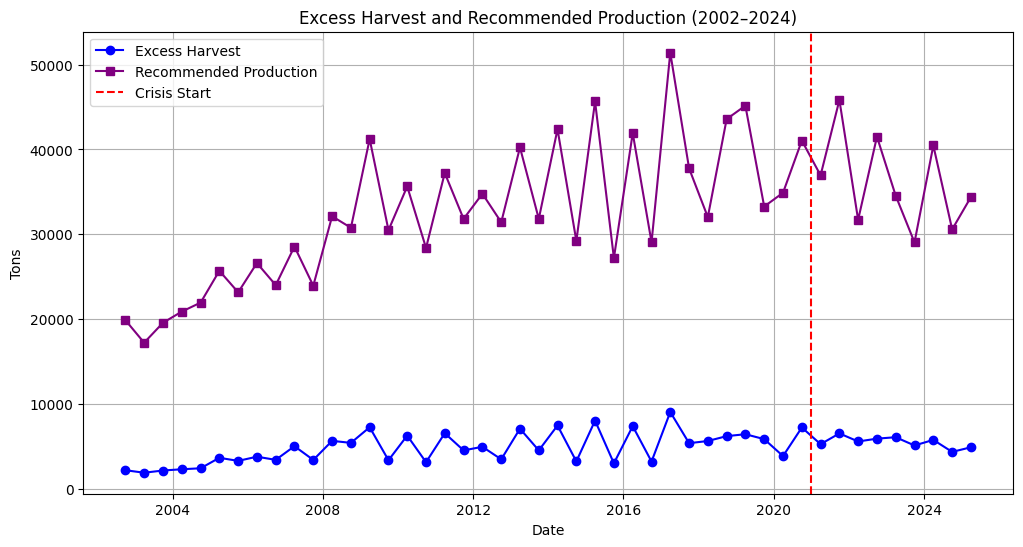

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], marker='o', linestyle='-', label='Excess Harvest', color='blue')
plt.plot(df['ds'], df['production'] - df['y'], marker='s', linestyle='-', label='Recommended Production', color='purple')
plt.axvline(pd.to_datetime('2021-01-01'), color='r', linestyle='--', label='Crisis Start')
plt.title('Excess Harvest and Recommended Production (2002–2024)')
plt.xlabel('Date')
plt.ylabel('Tons')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

ann_df = df[['ds', 'y', 'production']].copy()

ann_df = ann_df.sort_values('ds').reset_index(drop=True)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(ann_df[['production', 'y']])
scaled_df = pd.DataFrame(scaled, columns=['production', 'y'])
scaled_df['ds'] = ann_df['ds']

X, y = [], []
for i in range(len(scaled_df) - 1):
    X.append(scaled_df[['production', 'y']].iloc[i].values)
    y.append(scaled_df['y'].iloc[i + 1])
X, y = np.array(X), np.array(y)

tf.random.set_seed(42)
model = Sequential([
    Dense(64, activation='relu', input_dim=2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=300, batch_size=8, verbose=0)

last_known = scaled_df[['production', 'y']].iloc[-1].values.reshape(1, -1)

future_predictions = []
future_dates = pd.date_range(start=ann_df['ds'].iloc[-1], periods=3, freq='6M')[1:]

for _ in range(2):
    next_pred = model.predict(last_known)
    future_predictions.append(next_pred[0][0])
    new_prod = last_known[0][0] * np.random.uniform(1.02, 1.05)
    last_known = np.array([[new_prod, next_pred[0][0]]])

all_preds_scaled = np.concatenate([y[-2:], future_predictions])
dummy = np.zeros((len(all_preds_scaled), 2))
dummy[:, 1] = all_preds_scaled
inversed = scaler.inverse_transform(dummy)
forecast_values = inversed[:, 1][-2:]

forecast_df = pd.DataFrame({
    'ds': future_dates,
    'yhat': forecast_values,
    'yhat_lower': forecast_values * 0.95,
    'yhat_upper': forecast_values * 1.05
})

print("2026 Excess Forecast:\n")
print(forecast_df)

C:\Users\DELL\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


C:\Users\DELL\AppData\Local\Temp\ipykernel_19244\753114277.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=ann_df['ds'].iloc[-1], periods=3, freq='6M')[1:]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2026 Excess Forecast:

          ds         yhat   yhat_lower   yhat_upper
0 2025-09-30  5659.161506  5376.203431  5942.119582
1 2026-03-31  4883.927523  4639.731147  5128.123900


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

ann_prod = df[['ds', 'production']].copy()
ann_prod = ann_prod.sort_values('ds').reset_index(drop=True)

scaler_prod = MinMaxScaler()
ann_prod['production_scaled'] = scaler_prod.fit_transform(ann_prod[['production']])

for lag in range(1, 4):
    ann_prod[f'lag_prod_{lag}'] = ann_prod['production_scaled'].shift(lag)

ann_prod.dropna(inplace=True)

X = ann_prod[[f'lag_prod_{i}' for i in range(1, 4)]]
y = ann_prod['production_scaled']

model_prod = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
model_prod.fit(X, y)

X_last = X.tail(1).values
future_preds_prod = []

for i in range(2):
    prod_pred = model_prod.predict(X_last)[0]
    future_preds_prod.append(prod_pred)
    
    new_input = np.append(X_last.flatten()[1:], prod_pred).reshape(1, -1)
    X_last = new_input

future_preds_prod = scaler_prod.inverse_transform(np.array(future_preds_prod).reshape(-1, 1)).flatten()

future_preds_excess = forecast_df['yhat'].values

recommended_production = future_preds_prod - future_preds_excess

future_dates = forecast_df['ds'].values
forecast_combined = pd.DataFrame({
    'ds': future_dates,
    'Forecasted_Production': future_preds_prod,
    'Forecasted_Excess': future_preds_excess,
    'Recommended_Production': recommended_production
})

print("2026 Recommendations:\n")
print(forecast_combined)

2026 Recommendations:

          ds  Forecasted_Production  Forecasted_Excess  Recommended_Production
0 2025-09-30           42459.746546        5659.161506             36800.58504
1 2026-03-31           43402.832654        4883.927523             38518.90513


C:\Users\DELL\tf_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\DELL\tf_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from math import sqrt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

real_dates = pd.to_datetime([
    '2002-09-30', '2003-03-31', '2003-09-30', '2004-03-31', '2004-09-30', '2005-03-31',
    '2005-09-30', '2006-03-31', '2006-09-30', '2007-03-31', '2007-09-30', '2008-03-31',
    '2008-09-30', '2009-03-31', '2009-09-30', '2010-03-31', '2010-09-30', '2011-03-31',
    '2011-09-30', '2012-03-31', '2012-09-30', '2013-03-31', '2013-09-30', '2014-03-31',
    '2014-09-30', '2015-03-31', '2015-09-30', '2016-03-31', '2016-09-30', '2017-03-31',
    '2017-09-30', '2018-03-31', '2018-09-30', '2019-03-31', '2019-09-30', '2020-03-31',
    '2020-09-30', '2021-03-31', '2021-09-30', '2022-03-31', '2022-09-30', '2023-03-31',
    '2023-09-30', '2024-03-31', '2024-09-30', '2025-03-31'
])
real_production = [22092.00, 19146.00, 21756.00, 23219.00, 24395.00, 29373.00, 26477.00, 30417.00, 27443.00, 33600.00, 27364.00, 37793.00, 36202.00, 
              48496.00, 33873.00, 41930.00, 31544.00, 43791.00, 36364.00, 39749.00, 34911.00, 47339.00, 36365.00, 49861.00, 32464.00, 53708.00, 
              30228.00, 49325.00, 32286.00, 60462.00, 43159.00, 37680.00, 49797.00, 51607.00, 39145.00, 38771.00, 48284.10, 42223.00, 52365.80, 
              37302.90, 47424.90, 40656.10, 34169.30, 46244.20, 34945.00, 39292.90]
real_excess = [2209.2, 1914.6, 2175.6, 2321.9, 2439.5, 3671.6, 3309.6, 3802.1, 3430.3, 5040, 3420.5, 5669, 5430.3, 7274.4, 3387.3, 6289.5, 3154.4, 
          6568.7, 4545.5, 4968.6, 3491.1, 7100.9, 4545.6, 7479.1, 3246.4, 8056.2, 3022.8, 7398.8, 3228.6, 9069.3, 5394.9, 5652, 6224.6, 6450.90, 
          5871.80, 3877.1, 7242.6, 5278, 6545.70, 5595.40, 5928.1, 6098, 5125, 5780.50, 4368.1, 4911.6]

df_train = pd.DataFrame({
    'ds': real_dates,
    'production': real_production,
    'y': real_excess,
    'season': ['Yala', 'Maha'] * 23,
    'period': ['Pre-Crisis'] * 38 + ['Post-Crisis'] * 8
})

dates_test = pd.to_datetime([
    '2015-09-30', '2016-03-31', '2016-09-30', '2017-03-31', '2017-09-30', '2018-03-31',
    '2018-09-30', '2019-03-31', '2019-09-30', '2020-03-31', '2020-09-30', '2021-03-31',
    '2021-09-30', '2022-03-31', '2022-09-30', '2023-03-31', '2023-09-30', '2024-03-31',
    '2024-09-30', '2025-03-31'
])
production_test = np.array([30228.00, 49325.00, 32286.00, 60462.00, 43159.00, 37680.00, 49797.00, 51607.00,
                            39145.00, 38771.00, 48284.10, 42223.00, 52365.80, 37302.90, 47424.90, 40656.10,
                            34169.30, 46244.20, 34945.00, 39292.90])
synthetic_excess = np.array([3022.8, 7398.75, 3228.6, 9069.30, 4315.9, 5652.00, 4979.7, 7741.05,
                             3914.5, 5815.65, 4828.4, 6333.45, 5236.6, 5595.44, 4742.5, 6098.42,
                             3416.9, 6936.63, 3494.5, 5893.94])
avg_ratio = 0.12
synthetic_excess = ((synthetic_excess * 0.7) + (production_test * avg_ratio * 0.3)) * np.random.uniform(0.999, 1.001, len(synthetic_excess))

df_test = pd.DataFrame({
    'ds': dates_test,
    'production': production_test,
    'y': synthetic_excess,
    'season': ['Yala', 'Maha'] * 10
})

df_test['period'] = np.where(df_test['ds'] < '2021-01-01', 'Pre-Crisis', 'Post-Crisis')

df_train['season_encoded'] = df_train['season'].map({'Yala': 0, 'Maha': 1})
df_train['period_encoded'] = df_train['period'].map({'Pre-Crisis': 0, 'Post-Crisis': 1})
df_test['season_encoded'] = df_test['season'].map({'Yala': 0, 'Maha': 1})
df_test['period_encoded'] = df_test['period'].map({'Pre-Crisis': 0, 'Post-Crisis': 1})

feature_cols = ['production', 'season_encoded', 'period_encoded']
X_train = df_train[feature_cols]
y_train = df_train['y'].values
X_test = df_test[feature_cols]
y_test = df_test['y'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

model.fit(X_train_scaled, y_train, epochs=1000, batch_size=4, callbacks=[es], verbose=1)

y_pred = model.predict(X_test_scaled).flatten()
df_test['y_pred'] = y_pred

mae  = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / np.clip(y_test, 1e-6, None))) * 100
accuracy = 100 - mape

print("Accuracy \n")
print(f"MAE: {mae:,.2f} tons")
print(f"RMSE: {rmse:,.2f} tons")
print(f"R²: {r2:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

Epoch 1/1000


C:\Users\DELL\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 27567066.0000
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27560404.0000 
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27548416.0000 
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27526348.0000 
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27482054.0000 
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27404500.0000 
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27262344.0000 
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26977330.0000 
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26593152.0000 
Epoch 10/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26018036.0000 
Epoch 11/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25104016.0000 
Epoch 12/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24011696.0000 
Epoch 13/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22411980.0000 
Epoch 14/1000
12/12 ━━━━━━━━━━━━━━━

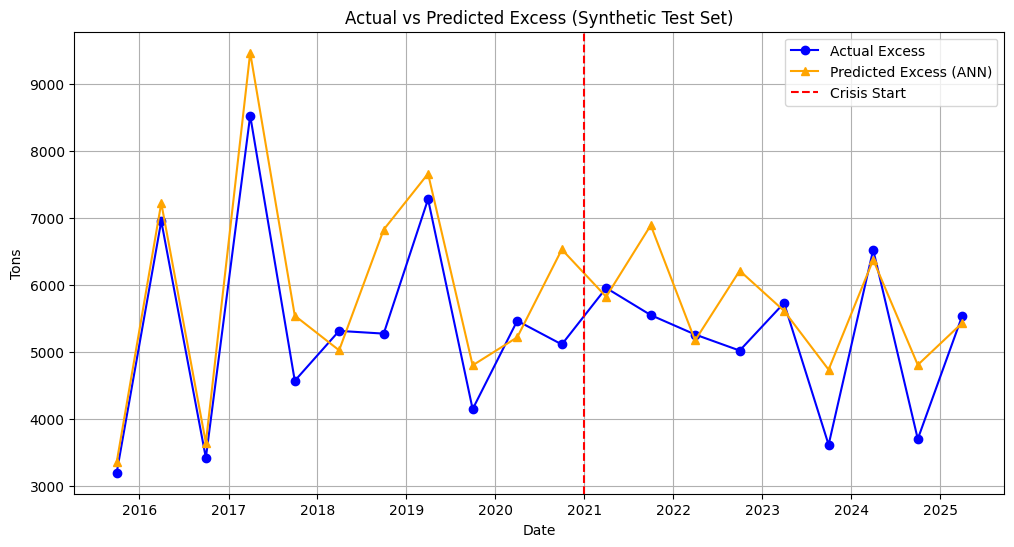

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df_test['ds'], df_test['y'], 'o-', label='Actual Excess', color='blue')
plt.plot(df_test['ds'], df_test['y_pred'], '^-', label='Predicted Excess (ANN)', color='orange')
plt.axvline(pd.to_datetime('2021-01-01'), color='r', linestyle='--',label='Crisis Start')

plt.title('Actual vs Predicted Excess (Synthetic Test Set)')
plt.xlabel('Date'); plt.ylabel('Tons')
plt.legend(); 
plt.grid(True); 
plt.show()

In [7]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\DELL\tf_env\Scripts\python.exe -m pip install --upgrade pip


Trial 20 Complete [00h 02m 05s]
val_mae: 5113.619140625

Best val_mae So Far: 568.6943969726562
Total elapsed time: 00h 42m 01s
BEST HYPERPARAMETERS FOUND:
  units: 128
  dropout: 0.1
  add_hidden: True
  lr: 0.001576823467859262
  hidden_units: 128
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


SCALER PARAMETERS:
Scaler mean (production, season, period): [3.62191533e+04 4.66666667e-01 1.33333333e-01]
Scaler scale (std dev): [9.71588681e+03 4.98887652e-01 3.39934634e-01]
Scaler variance: [9.43984565e+07 2.48888889e-01 1.15555556e-01]


TRAINING VS TESTING PERFORMANCE:
Training Accuracy : 87.52% (MAE: 527.3 tons)
Testing Accuracy  : 90.33% (MAE: 466.9 tons)


OVERALL PERFORMANCE (FULL DATASET):
Mean Absolute Error (MAE) : 521.6 tons
Root Mean Square Error (RMSE): 646.21 tons
R² Score                  : 0.8598
Accuracy (100-MAPE)       : 88.48%


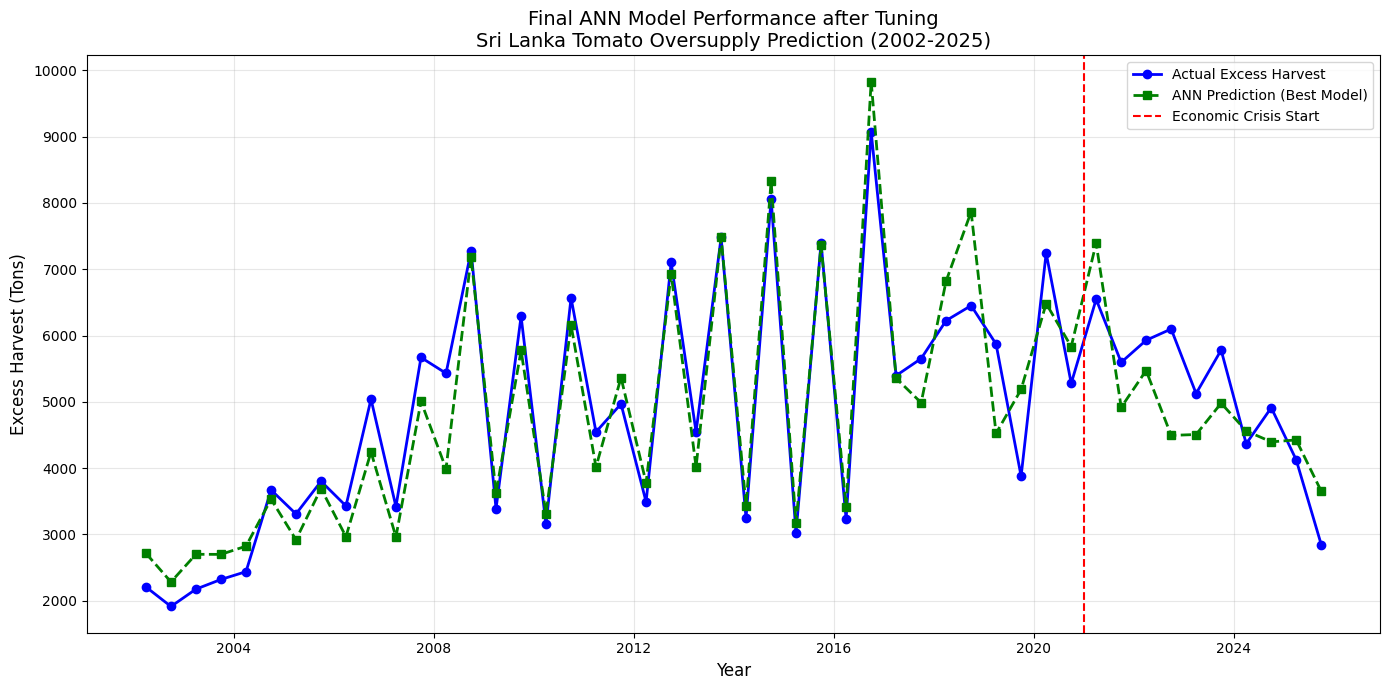


Scaler saved as: tomato_scaler.pkl

Model saved as: best_tomato_ann_srilanka_2026_final.h5


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. DATA PREPARATION
dates = pd.to_datetime([
    '2002-03-31', '2002-09-30', '2003-03-31', '2003-09-30', '2004-03-31', '2004-09-30', 
    '2005-03-31', '2005-09-30', '2006-03-31', '2006-09-30', '2007-03-31', '2007-09-30', 
    '2008-03-31', '2008-09-30', '2009-03-31', '2009-09-30', '2010-03-31', '2010-09-30', 
    '2011-03-31', '2011-09-30', '2012-03-31', '2012-09-30', '2013-03-31', '2013-09-30', 
    '2014-03-31', '2014-09-30', '2015-03-31', '2015-09-30', '2016-03-31', '2016-09-30', 
    '2017-03-31', '2017-09-30', '2018-03-31', '2018-09-30', '2019-03-31', '2019-09-30', 
    '2020-03-31', '2020-09-30', '2021-03-31', '2021-09-30', '2022-03-31', '2022-09-30', 
    '2023-03-31', '2023-09-30', '2024-03-31', '2024-09-30', '2025-03-31', '2025-09-30'
])

production = [22092.00, 19146.00, 21756.00, 23219.00, 24395.00, 29373.00, 26477.00, 30417.00,
              27443.00, 33600.00, 27364.00, 37793.00, 36202.00, 48496.00, 33873.00, 41930.00,
              31544.00, 43791.00, 36364.00, 39749.00, 34911.00, 47339.00, 36365.00, 49861.00,
              32464.00, 53708.00, 30228.00, 49325.00, 32286.00, 60462.00, 43159.00, 37680.00,
              49797.00, 51607.00, 39145.00, 38771.00, 48284.10, 42223.00, 52365.80, 37302.90,
              47424.90, 40656.10, 34169.30, 46244.20, 34945.00, 39292.90, 33011.9,	28479.6]

excess = [2209.2, 1914.6, 2175.6, 2321.9, 2439.5, 3671.6, 3309.6, 3802.1,
          3430.3, 5040, 3420.5, 5669, 5430.3, 7274.4, 3387.3, 6289.5,
          3154.4, 6568.7, 4545.5, 4968.6, 3491.1, 7100.9, 4545.6, 7479.1,
          3246.4, 8056.2, 3022.8, 7398.8, 3228.6, 9069.3, 5394.9, 5652,
          6224.6, 6450.90, 5871.80, 3877.1, 7242.6, 5278, 6545.70, 5595.40,
          5928.1, 6098, 5125, 5780.50, 4368.1, 4911.6, 4126.49, 2848]

df = pd.DataFrame({
    'ds': dates,
    'production': production,
    'y': excess,
    'season': ['Maha', 'Yala'] * 24,
    'period': ['Pre-Crisis'] * 40 + ['Post-Crisis'] * 8
})

df['season_encoded'] = df['season'].map({'Maha': 0, 'Yala': 1})
df['period_encoded'] = df['period'].map({'Pre-Crisis': 0, 'Post-Crisis': 1})

X = df[['production', 'season_encoded', 'period_encoded']].values
y = df['y'].values

# 2. DATA SPLITTING (Train, Validation, Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)

# 3. SCALING (Fit only on X_train to prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_full_scaled = scaler.transform(X)

# 4. TUNER DEFINITION
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(layers.Dense(
        units=hp.Int('units', 64, 256, step=32),
        activation='relu',
        input_shape=(3,)
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.1, 0.3, step=0.1)))

    if hp.Boolean('add_hidden'):
        model.add(layers.Dense(
            units=hp.Int('hidden_units', 32, 128, step=32),
            activation='relu'
        ))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr', 5e-4, 5e-3, sampling='log')),
        loss='mse',
        metrics=['mae']
    )
    return model

# 5. RUNNING THE TUNER
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=20,
    directory='tomato_tuning_results',
    project_name='fyp_final_model',
    overwrite=True
)

print("\nStarting hyperparameter tuning...")
tuner.search(
    X_train_scaled, y_train,
    epochs=600,
    validation_data=(X_val_scaled, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=40, restore_best_weights=True)],
    verbose=1
)

# 6. RETRIEVING THE BEST RESULTS
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("BEST HYPERPARAMETERS FOUND:")
for key, value in best_hps.values.items():
    print(f"  {key}: {value}")

# 7. PERFORMANCE EVALUATION
# Define a helper to calculate metrics consistently
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    accuracy = 100 - mape
    return mae, rmse, r2, accuracy

# Predictions for all splits
y_train_pred = best_model.predict(X_train_scaled).flatten()
y_test_pred = best_model.predict(X_test_scaled).flatten()
y_full_pred = best_model.predict(X_full_scaled).flatten()

# Calculate metrics for each set
train_mae, _, _, train_acc = calculate_metrics(y_train, y_train_pred)
test_mae, _, _, test_acc = calculate_metrics(y_test, y_test_pred)
full_mae, full_rmse, full_r2, full_acc = calculate_metrics(y, y_full_pred)

# Printing Scaler Details
print("\n")
print("SCALER PARAMETERS:")
print("Scaler mean (production, season, period):", scaler.mean_)
print("Scaler scale (std dev):", scaler.scale_)
print("Scaler variance:", scaler.var_)

# Performance breakdown
print("\n")
print("TRAINING VS TESTING PERFORMANCE:")
print(f"Training Accuracy : {train_acc:.2f}% (MAE: {train_mae:.1f} tons)")
print(f"Testing Accuracy  : {test_acc:.2f}% (MAE: {test_mae:.1f} tons)")

# Final Performance Summary
print("\n")
print("OVERALL PERFORMANCE (FULL DATASET):")
print(f"Mean Absolute Error (MAE) : {full_mae:.1f} tons")
print(f"Root Mean Square Error (RMSE): {full_rmse:,.2f} tons")
print(f"R² Score                  : {full_r2:.4f}")
print(f"Accuracy (100-MAPE)       : {full_acc:.2f}%")

# 8. VISUALIZATION
df['predicted_excess'] = y_full_pred
df_sorted = df.sort_values('ds')

plt.figure(figsize=(14, 7))
plt.plot(df_sorted['ds'], df_sorted['y'], 'o-', label='Actual Excess Harvest', color='blue', linewidth=2)
plt.plot(df_sorted['ds'], df_sorted['predicted_excess'], 's--', label='ANN Prediction (Best Model)', color='green', linewidth=2)
plt.axvline(pd.to_datetime('2021-01-01'), color='red', linestyle='--', label='Economic Crisis Start')
plt.title('Final ANN Model Performance after Tuning\nSri Lanka Tomato Oversupply Prediction (2002-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Excess Harvest (Tons)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. SAVE THE MODEL
joblib.dump(scaler, 'tomato_scaler.pkl')
print("\nScaler saved as: tomato_scaler.pkl")
best_model.save('best_tomato_ann_srilanka_2026_final.h5')
print("\nModel saved as: best_tomato_ann_srilanka_2026_final.h5")